# Data Cleaning: Urban Traffic Dataset

This notebook cleans `urban_traffic_dataset.csv` step by step and saves a cleaned file and a model-ready file.

**Pipeline**
1. Load and inspect
2. Duplicates and time-grid check
3. Calendar consistency
4. Impossible values
5. Sensor outliers (speed spikes)
6. Missing values: causal imputation (no future leakage)
7. Model-ready subset and export

Put `urban_traffic_dataset.csv` in the same folder as this notebook, then run all cells.

In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (10, 4)


SENSOR_COLS = ["avg_speed_kmh", "vehicle_density_per_km", "avg_waiting_time_sec", "queue_length_veh"]
BINARY_COLS = ["is_weekend", "is_holiday", "event_nearby", "incident_flag"]
LAG_COLS    = ["prev_count_15min", "prev_count_1h", "count_same_time_yesterday",
               "count_same_time_last_week", "rolling_mean_1h"]
TARGET_COLS = ["target_next_count", "target_congestion"]
VALID_LEVELS = ["Low", "Moderate", "High", "Severe"]

report = {}   # collects every change we make

## 1. Load and inspect

In [ ]:
df = pd.read_csv()
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
print("Unparseable timestamps:", df["timestamp"].isna().sum())
df = df.dropna(subset=["timestamp"])
df = df.sort_values(["intersection_id", "timestamp"]).reset_index(drop=True)

report["shape_before"] = list(df.shape)
print("Shape:", df.shape)
df.head()

Unparseable timestamps: 0
Shape: (69120, 24)


,timestamp,intersection_id,hour,minute,day_of_week,is_weekend,is_holiday,event_nearby,temperature_c,rain_mm_15min,road_capacity_veh_15min,vehicle_count,avg_speed_kmh,vehicle_density_per_km,avg_waiting_time_sec,queue_length_veh,incident_flag,prev_count_15min,prev_count_1h,count_same_time_yesterday,count_same_time_last_week,rolling_mean_1h,target_next_count,target_congestion
0,2025-01-06 00:00:00,INT_01_CBD,0,0,0,0,0,0,2.6,0.0,420,23,45.0,1.2,11.5,1.5,0,NaN,NaN,NaN,NaN,NaN,36.0,Low
1,2025-01-06 00:15:00,INT_01_CBD,0,15,0,0,0,0,2.7,0.0,420,36,45.0,4.1,3.4,0.3,0,23.0,NaN,NaN,NaN,NaN,28.0,Low
2,2025-01-06 00:30:00,INT_01_CBD,0,30,0,0,0,0,2.4,0.0,420,28,44.6,1.0,11.3,0.0,0,36.0,NaN,NaN,NaN,NaN,33.0,Low
3,2025-01-06 00:45:00,INT_01_CBD,0,45,0,0,0,0,1.5,0.0,420,33,41.1,3.0,5.8,0.4,0,28.0,NaN,NaN,NaN,NaN,19.0,Low
4,2025-01-06 01:00:00,INT_01_CBD,1,0,0,0,0,0,3.1,0.0,420,19,44.4,2.1,0.0,0.0,0,33.0,23.0,NaN,NaN,30.0,32.0,Low


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 69120 entries, 0 to 69119
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   timestamp                  69120 non-null  datetime64[us]
 1   intersection_id            69120 non-null  str           
 2   hour                       69120 non-null  int64         
 3   minute                     69120 non-null  int64         
 4   day_of_week                69120 non-null  int64         
 5   is_weekend                 69120 non-null  int64         
 6   is_holiday                 69120 non-null  int64         
 7   event_nearby               69120 non-null  int64         
 8   temperature_c              69120 non-null  float64       
 9   rain_mm_15min              69120 non-null  float64       
 10  road_capacity_veh_15min    69120 non-null  int64         
 11  vehicle_count              69120 non-null  int64         
 12  avg_speed_kmh  

In [4]:
df.describe().T.round(2)

,count,mean,min,25%,50%,75%,max,std
timestamp,69120,2025-04-05 23:52:30,2025-01-06 00:00:00,2025-02-19 23:56:15,2025-04-05 23:52:30,2025-05-20 23:48:45,2025-07-04 23:45:00,NaN
hour,69120.0,11.5,0.0,5.75,11.5,17.25,23.0,6.922237
minute,69120.0,22.5,0.0,11.25,22.5,33.75,45.0,16.770631
day_of_week,69120.0,2.972222,0.0,1.0,3.0,5.0,6.0,1.992864
is_weekend,69120.0,0.277778,0.0,0.0,0.0,1.0,1.0,0.447906
is_holiday,69120.0,0.022222,0.0,0.0,0.0,0.0,1.0,0.147407
event_nearby,69120.0,0.003241,0.0,0.0,0.0,0.0,1.0,0.056836
temperature_c,69120.0,17.247575,0.1,11.6,18.0,22.9,31.5,7.338541
rain_mm_15min,69120.0,0.311576,0.0,0.0,0.0,0.0,12.3,1.027159
road_capacity_veh_15min,69120.0,395.0,260.0,350.0,400.0,445.0,520.0,93.140354


### Missing values before cleaning

count_same_time_last_week    3.89 %
avg_waiting_time_sec         1.06 %
queue_length_veh             1.02 %
avg_speed_kmh                0.96 %
vehicle_density_per_km       0.92 %
count_same_time_yesterday    0.56 %
prev_count_1h                0.02 %
rolling_mean_1h              0.02 %
prev_count_15min             0.01 %
target_next_count            0.01 %
target_congestion            0.01 %
dtype: str


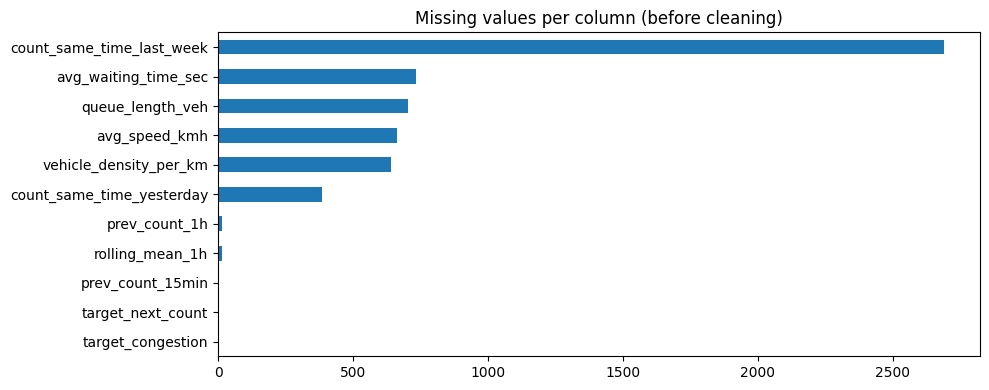

In [5]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
report["missing_before"] = missing.to_dict()
print((missing / len(df) * 100).round(2).astype(str) + " %")

missing.plot.barh(title="Missing values per column (before cleaning)")
plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()

**Reading this chart**
- The four **sensor columns** (~1% each) are real gaps: sensor dropouts.
- The **lag and target columns** are missing only at the start/end of each series (there is no "yesterday" for day 1). These are expected, so we do **not** impute them. We drop those rows later for modelling.

## 2. Duplicates and time grid

In [6]:
exact = df.duplicated().sum()
key   = df.duplicated(subset=["intersection_id", "timestamp"]).sum()
print("Exact duplicate rows:", exact, "| duplicate (intersection, timestamp):", key)

df = df.drop_duplicates().drop_duplicates(subset=["intersection_id", "timestamp"]).reset_index(drop=True)
report["duplicates_removed"] = int(exact + key)

Exact duplicate rows: 0 | duplicate (intersection, timestamp): 0


In [7]:
# every intersection should have one row every 15 minutes with no gaps
gaps = {}
for name, g in df.groupby("intersection_id"):
    full = pd.date_range(g["timestamp"].min(), g["timestamp"].max(), freq="15min")
    gaps[name] = int(len(full) - g["timestamp"].nunique())
report["missing_timestamps"] = gaps
print("Missing timestamps per intersection:", gaps)

Missing timestamps per intersection: {'INT_01_CBD': 0, 'INT_02_Arterial': 0, 'INT_03_Residential': 0, 'INT_04_Stadium': 0}


## 3. Calendar consistency

In [8]:
ts = df["timestamp"]
expected = {"hour": ts.dt.hour, "minute": ts.dt.minute,
            "day_of_week": ts.dt.dayofweek, "is_weekend": (ts.dt.dayofweek >= 5).astype(int)}
fixed = {}
for col, exp in expected.items():
    fixed[col] = int((df[col] != exp).sum())
    df[col] = exp.astype(int)
report["calendar_corrected"] = fixed
print("Calendar values that disagreed with the timestamp:", fixed)

Calendar values that disagreed with the timestamp: {'hour': 0, 'minute': 0, 'day_of_week': 0, 'is_weekend': 0}


## 4. Impossible values

In [9]:
rep = {}

# negative readings are impossible
for col in SENSOR_COLS + ["vehicle_count"]:
    neg = df[col] < 0
    rep[f"negative_{col}"] = int(neg.sum())
    df.loc[neg, col] = np.nan

# vehicle count above physical capacity (5% tolerance)
over = df["vehicle_count"] > df["road_capacity_veh_15min"] * 1.05
rep["count_over_capacity"] = int(over.sum())
df.loc[over, "vehicle_count"] = (df.loc[over, "road_capacity_veh_15min"] * 1.05).round()

# binary flags must be 0/1
for col in BINARY_COLS:
    bad = ~df[col].isin([0, 1])
    rep[f"invalid_{col}"] = int(bad.sum())
    df.loc[bad, col] = df.loc[~bad, col].mode().iloc[0]
    df[col] = df[col].astype(int)

# labels must be one of the 4 classes
bad_lbl = df["target_congestion"].notna() & ~df["target_congestion"].isin(VALID_LEVELS)
rep["invalid_labels"] = int(bad_lbl.sum())
df.loc[bad_lbl, "target_congestion"] = np.nan

report["impossible_values"] = rep
print(json.dumps(rep, indent=2))

{
  "negative_avg_speed_kmh": 0,
  "negative_vehicle_density_per_km": 0,
  "negative_avg_waiting_time_sec": 0,
  "negative_queue_length_veh": 0,
  "negative_vehicle_count": 0,
  "count_over_capacity": 0,
  "invalid_is_weekend": 0,
  "invalid_is_holiday": 0,
  "invalid_event_nearby": 0,
  "invalid_incident_flag": 0,
  "invalid_labels": 0
}


## 5. Sensor outliers (speed spikes)

We saw `avg_speed_kmh` readings far above what each road allows. Two rules flag them:

- **Hampel filter:** a jump far above the local rolling median (more than 12 robust sigmas)
- **Physical cap:** above 1.10 x the intersection's 99.5th percentile

Only **upward** spikes are removed. Sudden speed **drops** are real (incidents), so they stay.

In [10]:
speed_before = df["avg_speed_kmh"].copy()

HAMPEL_WINDOW, HAMPEL_K, SPEED_CAP_FACTOR = 9, 12.0, 1.10
flagged = pd.Series(False, index=df.index)
for name, g in df.groupby("intersection_id"):
    s = g["avg_speed_kmh"]
    med = s.rolling(HAMPEL_WINDOW, center=True, min_periods=3).median()
    dev = s - med
    mad = 1.4826 * dev.abs().median()
    cap = s.quantile(0.995) * SPEED_CAP_FACTOR
    flagged.loc[g.index] = (dev > HAMPEL_K * mad) | (s > cap)

report["speed_outliers"] = int(flagged.sum())
print("Speed outliers flagged:", flagged.sum())
df.loc[flagged, ["timestamp", "intersection_id", "avg_speed_kmh"]].head(10)

Speed outliers flagged: 25


,timestamp,intersection_id,avg_speed_kmh
4672,2025-02-23 16:00:00,INT_01_CBD,71.566090
4830,2025-02-25 07:30:00,INT_01_CBD,38.080058
13539,2025-05-27 00:45:00,INT_01_CBD,104.435328
13808,2025-05-29 20:00:00,INT_01_CBD,82.831015
20340,2025-02-06 21:00:00,INT_02_Arterial,127.203192
20919,2025-02-12 21:45:00,INT_02_Arterial,142.561678
22866,2025-03-05 04:30:00,INT_02_Arterial,146.062843
24458,2025-03-21 18:30:00,INT_02_Arterial,38.884388
25917,2025-04-05 23:15:00,INT_02_Arterial,140.417580
27130,2025-04-18 14:30:00,INT_02_Arterial,79.327354


/tmp/ipykernel_131/3828535973.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  lambda s: ax[0].boxplot(s.values, labels=[x[4:] for x in s.index]))
/tmp/ipykernel_131/3828535973.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  lambda s: ax[1].boxplot(s.values, labels=[x[4:] for x in s.index]))


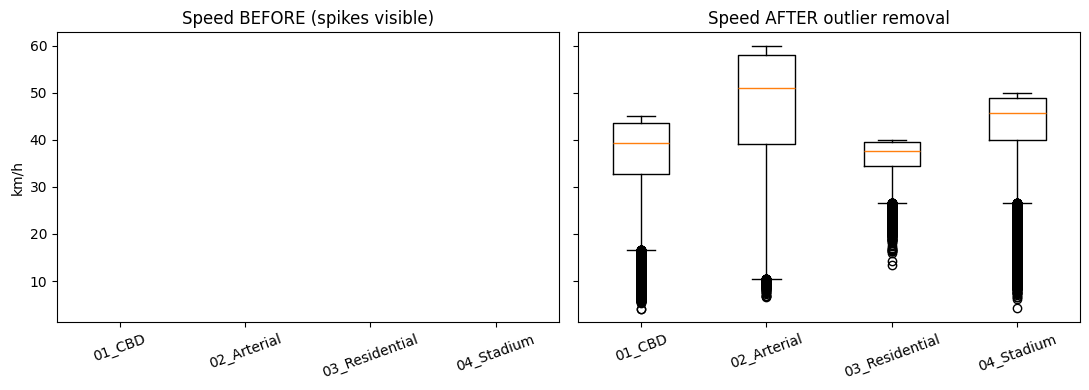

In [11]:
df.loc[flagged, "avg_speed_kmh"] = np.nan   # will be re-filled in step 6

fig, ax = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
speed_before.groupby(df["intersection_id"]).apply(list).pipe(
    lambda s: ax[0].boxplot(s.values, labels=[x[4:] for x in s.index]))
ax[0].set_title("Speed BEFORE (spikes visible)"); ax[0].tick_params(axis="x", rotation=20)
df.groupby("intersection_id")["avg_speed_kmh"].apply(lambda s: s.dropna().tolist()).pipe(
    lambda s: ax[1].boxplot(s.values, labels=[x[4:] for x in s.index]))
ax[1].set_title("Speed AFTER outlier removal"); ax[1].tick_params(axis="x", rotation=20)
ax[0].set_ylabel("km/h"); plt.tight_layout(); plt.show()

## 6. Missing sensor values: causal imputation

We fill gaps using **past information only**, so no future data leaks into the features:

1. **Forward-fill** the last reading for up to 4 steps (1 hour) within the same intersection
2. **Fallback:** the typical (median) value for that intersection, hour of day and weekday/weekend

We avoid linear interpolation on purpose, since it would use the *next* reading to fill the current one.

In [12]:
MAX_FFILL_STEPS = 4
rep = {"missing_before": {c: int(df[c].isna().sum()) for c in SENSOR_COLS}}

n_imputed = pd.Series(0, index=df.index)
for col in SENSOR_COLS:
    was_na = df[col].isna()
    df[col] = df.groupby("intersection_id")[col].ffill(limit=MAX_FFILL_STEPS)
    profile = df.groupby(["intersection_id", "hour", "is_weekend"])[col].transform("median")
    df[col] = df[col].fillna(profile)
    n_imputed += was_na.astype(int)

df["n_imputed_sensor_values"] = n_imputed      # keep a trace of what we filled
rep["missing_after"] = {c: int(df[c].isna().sum()) for c in SENSOR_COLS}
rep["rows_with_imputed_value"] = int((n_imputed > 0).sum())
report["imputation"] = rep
print(json.dumps(rep, indent=2))

{
  "missing_before": {
    "avg_speed_kmh": 686,
    "vehicle_density_per_km": 639,
    "avg_waiting_time_sec": 732,
    "queue_length_veh": 705
  },
  "missing_after": {
    "avg_speed_kmh": 0,
    "vehicle_density_per_km": 0,
    "avg_waiting_time_sec": 0,
    "queue_length_veh": 0
  },
  "rows_with_imputed_value": 2720
}


### Final type clean-up

In [13]:
df["intersection_id"] = df["intersection_id"].astype("category")
for col in SENSOR_COLS:
    df[col] = df[col].round(1)
for col in ["hour", "minute", "day_of_week", "vehicle_count", "road_capacity_veh_15min"] + BINARY_COLS:
    df[col] = df[col].astype("int32")

print("Remaining NaNs (lag/target edges only):")
print(df.isna().sum()[df.isna().sum() > 0])

Remaining NaNs (lag/target edges only):
prev_count_15min                4
prev_count_1h                  16
count_same_time_yesterday     384
count_same_time_last_week    2688
rolling_mean_1h                16
target_next_count               4
target_congestion               4
dtype: int64


## 7. Model-ready subset and export

Rows without complete lag features or targets (the very beginning and end of each series) cannot be used for training, so they are removed from the model-ready file. The full cleaned file keeps them.

In [14]:
ready = df.dropna(subset=LAG_COLS + TARGET_COLS).reset_index(drop=True)
report["shape_cleaned"] = list(df.shape)
report["shape_model_ready"] = list(ready.shape)
print("Cleaned:", df.shape, "| Model-ready:", ready.shape, "| NaNs in model-ready:", int(ready.isna().sum().sum()))

df.to_csv("urban_traffic_cleaned.csv", index=False)
ready.to_csv("urban_traffic_model_ready.csv", index=False)
with open("cleaning_report.json", "w") as f:
    json.dump(report, f, indent=2, default=str)
print("Saved: urban_traffic_cleaned.csv, urban_traffic_model_ready.csv, cleaning_report.json")

Cleaned: (69120, 25) | Model-ready: (66428, 25) | NaNs in model-ready: 0


Saved: urban_traffic_cleaned.csv, urban_traffic_model_ready.csv, cleaning_report.json


## Sanity check: the cleaned data keeps real traffic patterns

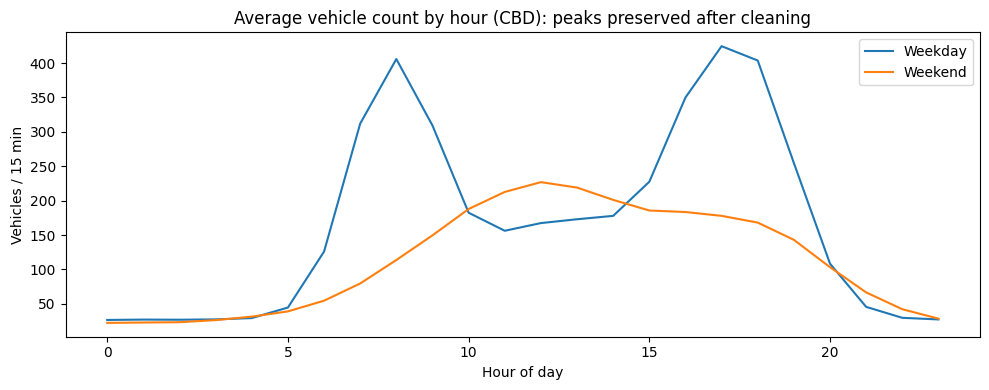

In [15]:
cbd = ready[ready["intersection_id"] == "INT_01_CBD"]
prof = cbd.groupby(["hour", "is_weekend"])["vehicle_count"].mean().unstack()
prof.columns = ["Weekday", "Weekend"]
prof.plot(title="Average vehicle count by hour (CBD): peaks preserved after cleaning")
plt.xlabel("Hour of day"); plt.ylabel("Vehicles / 15 min"); plt.tight_layout(); plt.show()

In [16]:
print("Congestion class balance (next 15 min):")
print(ready["target_congestion"].value_counts(normalize=True).round(3))

Congestion class balance (next 15 min):
target_congestion
Low         0.615
Moderate    0.229
Severe      0.083
High        0.073
Name: proportion, dtype: float64


## Summary of what was cleaned

| Issue | Action |
|---|---|
| ~1% missing sensor readings | Causal imputation (forward-fill, then typical profile) |
| Speed spikes (physically impossible) | Detected with Hampel filter + cap, then re-imputed |
| Lag/target NaNs at series edges | Kept in cleaned file, dropped in model-ready file |
| Duplicates, bad timestamps, invalid flags/labels | Checked (none found in this dataset), handled if present |

**Next step:** model on `urban_traffic_model_ready.csv` with a chronological train/test split, and do **not** use the `target_*` columns as features.